<a href="https://colab.research.google.com/github/jenny-alice-n/SDC-Generative-AI/blob/main/Image_generation_for_a_given_prompt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating image for prompt: a futuristic city skyline at sunset with flying cars and neon lights


  0%|          | 0/50 [00:00<?, ?it/s]

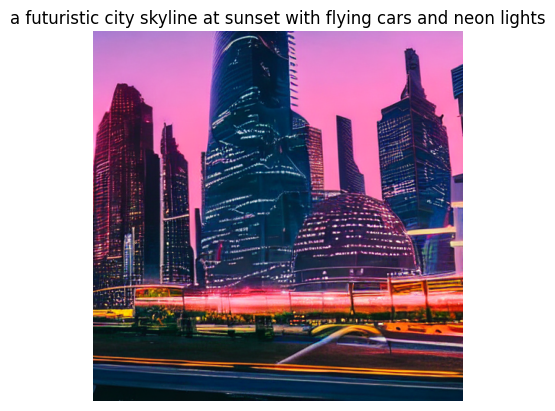

In [1]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Load the pre-trained Stable Diffusion model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda" if torch.cuda.is_available() else "cpu")

# Function to generate and display image from text
def generate_image(prompt):
    print("Generating image for prompt:", prompt)

    image = pipe(prompt).images[0]

    # Show the image
    plt.imshow(image)
    plt.axis("off")
    plt.title(prompt)
    plt.show()

    # Save the image if needed
    image.save("generated_image.png")

# Example usage
generate_image("a futuristic city skyline at sunset with flying cars and neon lights")


In [2]:
from transformers import pipeline

# Load the summarization pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Text to summarize
text = """
Artificial intelligence (AI) refers to the simulation of human intelligence in machines
that are programmed to think like humans and mimic their actions. The term may also be
applied to any machine that exhibits traits associated with a human mind such as learning
and problem-solving. AI is continuously evolving to benefit many different industries.
Machines are wired using a cross-disciplinary approach based on mathematics, computer science,
linguistics, psychology, and more. As AI systems become increasingly sophisticated, they are
being used in applications ranging from healthcare and finance to transportation and customer service.
"""

# Generate a more varied summary
summary = summarizer(
    text,
    max_length=100,
    min_length=40,
    do_sample=True,       # Enable sampling
    top_k=50,             # Sample from top 50 tokens
    top_p=0.95,           # Use nucleus sampling (95% cumulative probability)
    temperature=0.9       # Add randomness
)[0]['summary_text']

# Print the summary
print("Summary:\n", summary)


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


Summary:
 Artificial intelligence (AI) refers to the simulation of human intelligence in machines. Machines are programmed to think like humans and mimic their actions. As AI systems become increasingly sophisticated, they are being used in applications ranging from healthcare and finance to transportation and customer service.
